In [1]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib as mpl

from utils import savefig

plt.rcParams['font.size'] = 14

In [2]:
def load_data(path, training_data_path, model_num, exp, paramters, training_data_length=200):
    data_single_model = {}
    with open(path/"contiguity_effect.csv", "r") as f:
        reader = csv.reader(f)
        for row in reader:
            data_single_model["model_num"] = model_num
            data_single_model["exp"] = exp

            for key, value in paramters.items():
                data_single_model[key] = value

            data_single_model["accuracy"] = float(row[0])
            data_single_model["forward_asymmetry"] = float(row[1])
            data_single_model["temporal_factor"] = float(row[2])

            classifier_data = pickle.load(open(path/"ridge_classifier_stat.pkl", "rb"))
            data_single_model["index_decoding_accuracy_encoding_phase"] = classifier_data["index_enc_acc"]
            data_single_model["item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc"]
            data_single_model["last_item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc_last"]
            data_single_model["index_decoding_accuracy_recall_phase"] = classifier_data["index_rec_acc"]
            data_single_model["item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc"]
            data_single_model["last_item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc_last"]
            data_single_model["index_decoding_accuracy"] = (data_single_model["index_decoding_accuracy_encoding_phase"] + data_single_model["index_decoding_accuracy_recall_phase"]) / 2
            data_single_model["item_decoding_accuracy"] = (data_single_model["item_decoding_accuracy_encoding_phase"] + data_single_model["item_decoding_accuracy_recall_phase"]) / 2
            data_single_model["last_item_decoding_accuracy"] = (data_single_model["last_item_decoding_accuracy_encoding_phase"] + data_single_model["last_item_decoding_accuracy_recall_phase"]) / 2

            explained_variance_data = np.load(path/"explained_variance.npy")
            data_single_model["explained_variance_encoding_index"] = explained_variance_data[0]
            data_single_model["explained_variance_recall_index"] = explained_variance_data[1]
            data_single_model["explained_variance_index"] = (data_single_model["explained_variance_encoding_index"] + data_single_model["explained_variance_recall_index"]) / 2
            data_single_model["explained_variance_encoding_identity"] = explained_variance_data[2]
            data_single_model["explained_variance_recall_identity"] = explained_variance_data[3]
            data_single_model["explained_variance_identity"] = (data_single_model["explained_variance_encoding_identity"] + data_single_model["explained_variance_recall_identity"]) / 2

            cross_decoding_data = np.load(path/"cross_acc.npy")
            data_single_model["cross_decoding_accuracy_index_rec_enc"] = cross_decoding_data[0]
            data_single_model["cross_decoding_accuracy_identity_rec_enc"] = cross_decoding_data[1]
            data_single_model["cross_decoding_accuracy_index_enc_rec"] = cross_decoding_data[2]
            data_single_model["cross_decoding_accuracy_identity_enc_rec"] = cross_decoding_data[3]
            data_single_model["cross_decoding_accuracy_index"] = (data_single_model["cross_decoding_accuracy_index_rec_enc"] + data_single_model["cross_decoding_accuracy_index_enc_rec"]) / 2
            data_single_model["cross_decoding_accuracy_identity"] = (data_single_model["cross_decoding_accuracy_identity_rec_enc"] + data_single_model["cross_decoding_accuracy_identity_enc_rec"]) / 2

            try:
                training_data = np.load(training_data_path/"accuracy_2.npy")
            except:
                training_data = np.load(training_data_path/"accuracy_1.npy")
            # find the final consecutive zeros in the training data and set it to the last non-zero value
            zero_indices = np.where(training_data == 0)[0]
            if len(zero_indices) > 0:
                last_zero_index = zero_indices[0]
                training_data[last_zero_index:] = training_data[last_zero_index-1]
            if training_data.shape[0] < training_data_length and training_data.shape[0] > 0:
                training_data = np.pad(training_data, (0, training_data_length - training_data.shape[0]), mode='constant', constant_values=training_data[-1])
            data_single_model["training_accuracy"] = training_data

            f_recall_prob = open(path/"recall_probability.csv", "r")
            for row in f_recall_prob:
                data_single_model["crp_curve"] = [float(x) for x in row.strip().split(",")]
                break
            break
    return data_single_model


In [14]:
data_ctx = []

data_folder = Path("./experiments/ExtraObs/EnvCxt/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/EnvCxt/saved_models/ValueMemoryGRU")


setup_base_name = "setup_randnoise"
# setup_names = ["setup_gaussiannoise0", "setup_gaussiannoise02", "setup_gaussiannoise04", "setup_gaussiannoise06", "setup_gaussiannoise08", "setup_gaussiannoise1"]
# noise_stds = [0, 0.2, 0.4, 0.6, 0.8, 1]
noise_stds = [0, 0.4, 0.8, 1.2, 1.6]

setup_names = []
for noise_std in noise_stds:
    setup_names.append(setup_base_name + str(noise_std).replace(".", ""))



seq_len = 8

exp = "ctx"

for setup_name, noise_std in zip(setup_names, noise_stds):
    parameters = {
        "noise_std": noise_std,
        "seq_len": seq_len,
    }
    
    training_data_length = 200
    for i in range(20):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                # perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                # data_single_model["perturbation_accuracy"] = perturbation_data
                # if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["item_invariance_accuracy"] = item_invariance_data
                #     item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                # else:
                #     data_single_model["item_invariance_accuracy"] = None
                #     data_single_model["item_invariance_cross_phase_accuracy"] = None
                # if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["time_invariance_accuracy"] = time_invariance_data
                #     time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                # else:
                #     data_single_model["time_invariance_accuracy"] = None
                #     data_single_model["time_invariance_cross_phase_accuracy"] = None
                data_ctx.append(data_single_model)

df_ctx = pd.DataFrame(data_ctx)
# df_ctx = df_ctx[df_ctx["accuracy"] > 0.7]
print(len(df_ctx))

70


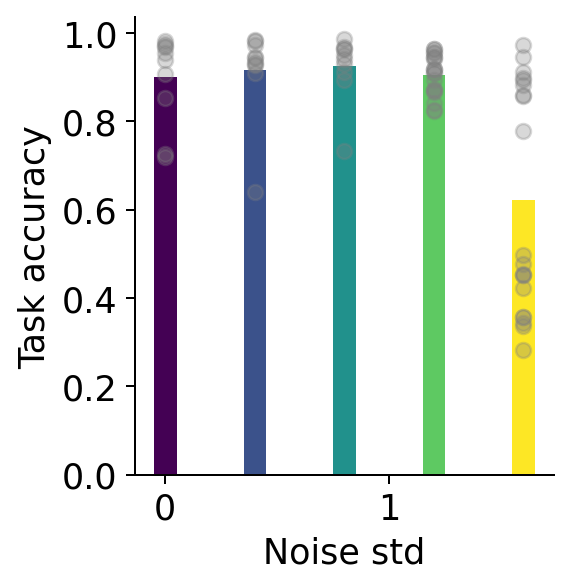

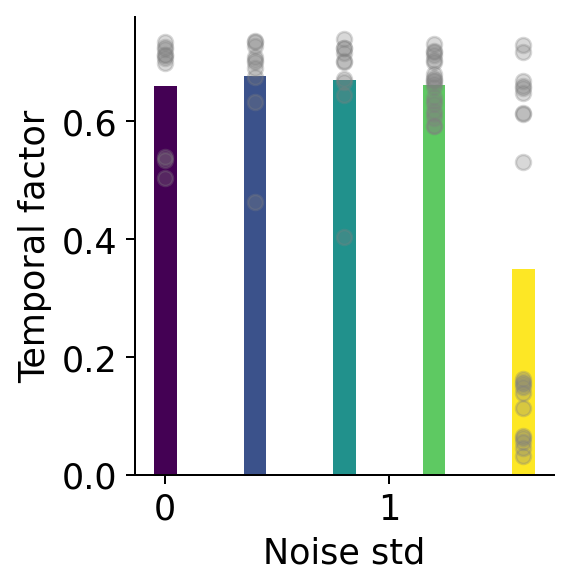

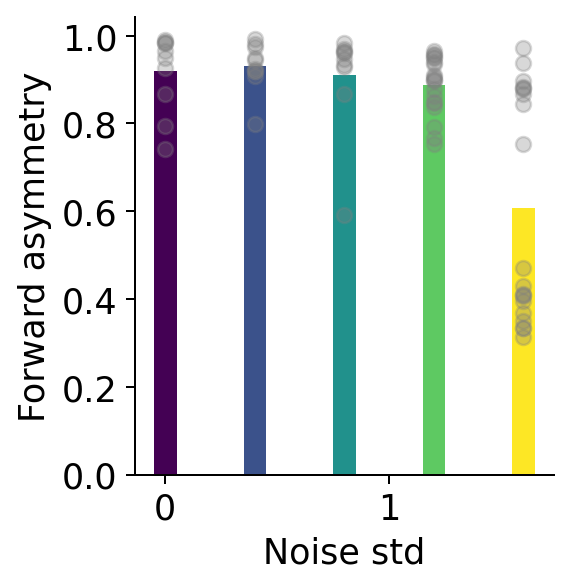

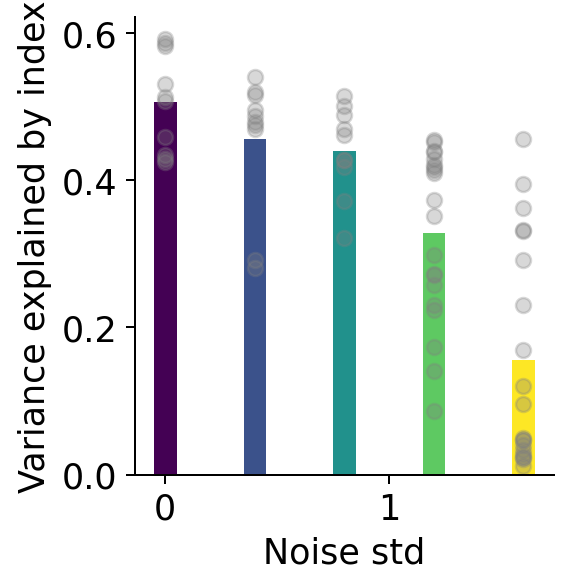

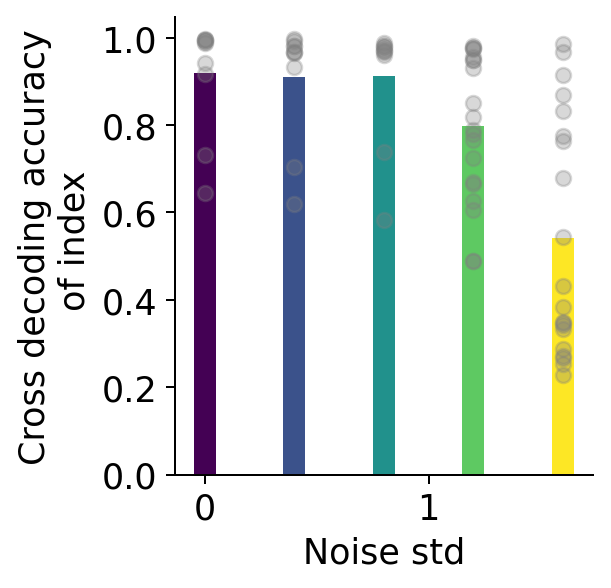

In [15]:
# bar plot of each metric for each noise std

accuracy_mean_by_noise_std = df_ctx.groupby("noise_std")["accuracy"].mean()
accuracy_std_by_noise_std = df_ctx.groupby("noise_std")["accuracy"].std()

temporal_factor_mean_by_noise_std = df_ctx.groupby("noise_std")["temporal_factor"].mean()
temporal_factor_std_by_noise_std = df_ctx.groupby("noise_std")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_std = df_ctx.groupby("noise_std")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_std = df_ctx.groupby("noise_std")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_std = df_ctx.groupby("noise_std")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_std = df_ctx.groupby("noise_std")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_std = df_ctx.groupby("noise_std")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_std = df_ctx.groupby("noise_std")["cross_decoding_accuracy_identity"].mean()


viridis = plt.get_cmap('viridis', lut=len(noise_stds))
colors = [viridis(i) for i in range(len(noise_stds))]

def plot_mean_scatter_bar(mean, df, df_label, noise_stds, y_label):
    plt.figure(figsize=(3, 3.3), dpi=180)
    plt.bar(noise_stds, mean, width=0.1, color=colors)
    plt.scatter(df["noise_std"], df[df_label], color="gray", alpha=0.3)
    plt.xlabel("Noise std")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

plot_mean_scatter_bar(accuracy_mean_by_noise_std, df_ctx, "accuracy", noise_stds, "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_std, df_ctx, "temporal_factor", noise_stds, "Temporal factor")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_std, df_ctx, "forward_asymmetry", noise_stds, "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_std, df_ctx, "explained_variance_index", noise_stds, "Variance explained by index")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_std, df_ctx, "cross_decoding_accuracy_index", noise_stds, "Cross decoding accuracy\n of index")


In [7]:
def plot_crp_by_group(data, group_values, group_title, colors):
    plt.figure(figsize=(4, 3.3), dpi=180)

    mid_point = data.shape[1] // 2 + 1

    for i in range(len(group_values)):
        plt.plot(np.arange(-mid_point, 0), data[i, :mid_point], label=group_values[i], color=colors[i])
        plt.plot(np.arange(1, mid_point), data[i, mid_point:], color=colors[i])
    
    plt.xlabel("Lag")
    plt.ylabel("Conditional\nrecall probability")
    plt.legend(
        title=group_title, 
        bbox_to_anchor=(1.0, 1.0), 
        loc="upper left", 
        borderaxespad=0, 
        frameon=False
    )
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()

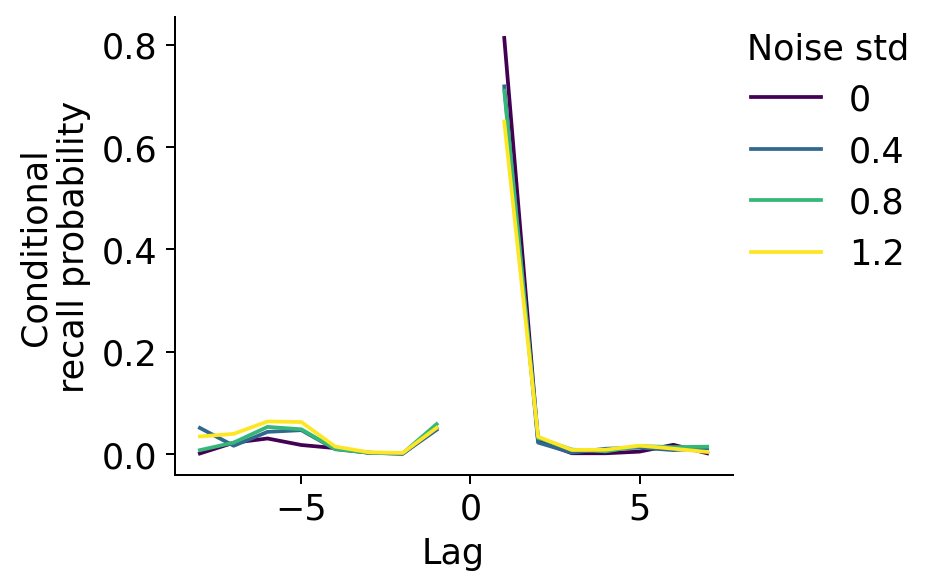

In [8]:
crp_by_noise_std = df_ctx.groupby("noise_std")["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std = []
for name, group in crp_by_noise_std:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std.append(mean_crp)
mean_crp_by_noise_std = np.array(mean_crp_by_noise_std)

viridis = plt.get_cmap('viridis', lut=len(noise_stds))
colors = [viridis(i) for i in range(len(noise_stds))]

plot_crp_by_group(mean_crp_by_noise_std, noise_stds, "Noise std", colors)



In [9]:
data_samediff = []

data_folder = Path("./experiments/ExtraObs/RecallCtx/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/RecallCtx/saved_models/ValueMemoryGRU")

setup_names = ["setup_gaussiannoise04_dim41_baseline", "setup_gaussiannoise04_dim41_same", "setup_gaussiannoise04_dim41_diff"]
# setup_names = ["setup_gaussiannoise1_baseline", "setup_gaussiannoise1_same", "setup_gaussiannoise1_diff"]
noise_types = ["no", "same", "diff"]

seq_len = 8

exp = "ctx"

for setup_name, noise_type in zip(setup_names, noise_types):
    parameters = {
        "noise_type": noise_type,
        "seq_len": seq_len,
    }
    
    training_data_length = 200
    for i in range(10):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                # perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                # data_single_model["perturbation_accuracy"] = perturbation_data
                # if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["item_invariance_accuracy"] = item_invariance_data
                #     item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                # else:
                #     data_single_model["item_invariance_accuracy"] = None
                #     data_single_model["item_invariance_cross_phase_accuracy"] = None
                # if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["time_invariance_accuracy"] = time_invariance_data
                #     time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                # else:
                #     data_single_model["time_invariance_accuracy"] = None
                #     data_single_model["time_invariance_cross_phase_accuracy"] = None
                data_samediff.append(data_single_model)

df_samediff = pd.DataFrame(data_samediff)
print(len(data_samediff))
df_samediff = df_samediff[df_samediff["accuracy"] > 0.7]

30


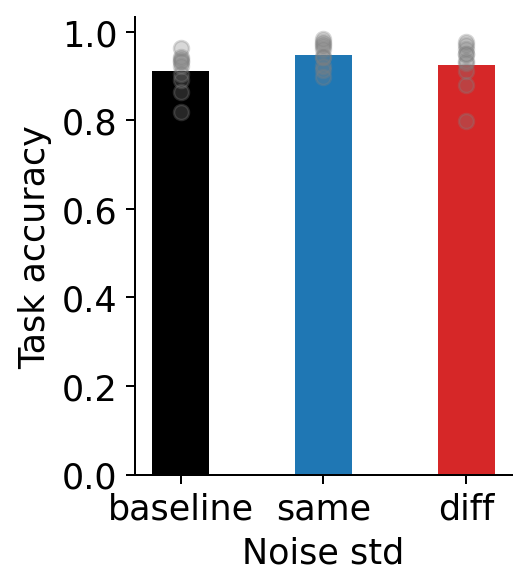

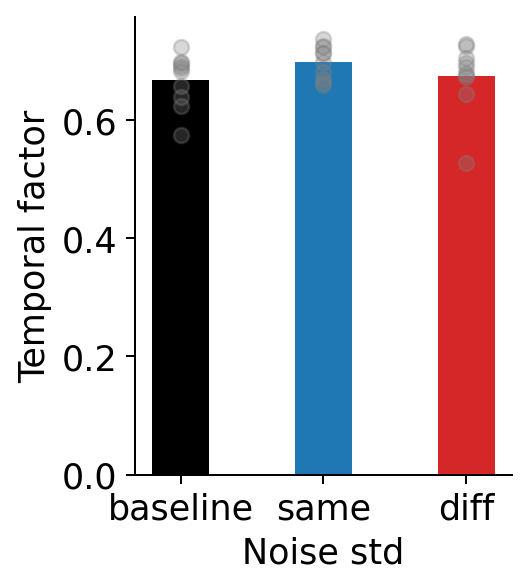

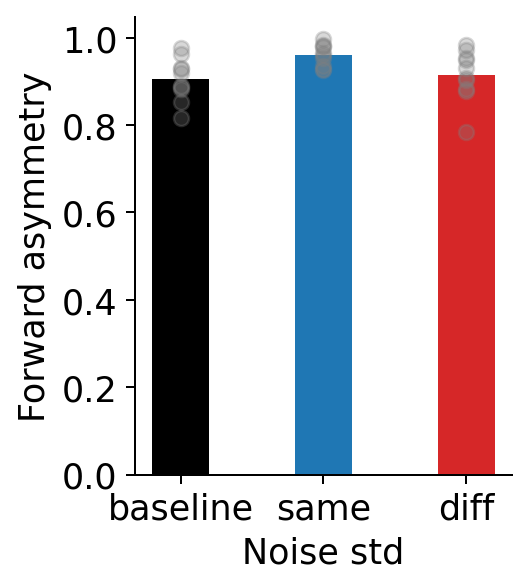

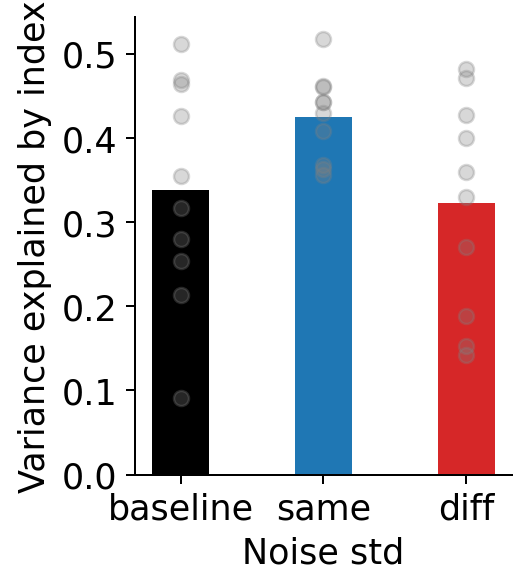

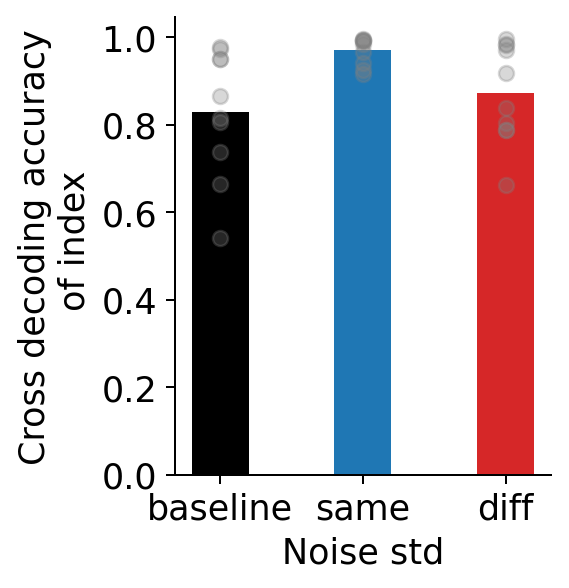

In [90]:
# bar plot of each metric for each noise std

df_samediff["noise_type_int"] = df_samediff["noise_type"].map({"no": 0, "same": 1, "diff": 2})

accuracy_mean_by_noise_type = df_samediff.groupby("noise_type_int")["accuracy"].mean()
accuracy_std_by_noise_type = df_samediff.groupby("noise_type_int")["accuracy"].std()

temporal_factor_mean_by_noise_type = df_samediff.groupby("noise_type_int")["temporal_factor"].mean()
temporal_factor_std_by_noise_type = df_samediff.groupby("noise_type_int")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_type = df_samediff.groupby("noise_type_int")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_type = df_samediff.groupby("noise_type_int")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_type = df_samediff.groupby("noise_type_int")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_type = df_samediff.groupby("noise_type_int")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_type = df_samediff.groupby("noise_type_int")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_type = df_samediff.groupby("noise_type_int")["cross_decoding_accuracy_identity"].mean()


colors = ["black", "tab:blue", "tab:red"]

def plot_mean_scatter_bar(mean, df, df_label, noise_stds, y_label):
    plt.figure(figsize=(2.7, 3.3), dpi=180)
    plt.bar(np.arange(3), mean, width=0.4, color=colors)
    plt.scatter(df["noise_type_int"], df[df_label], color="gray", alpha=0.3)
    plt.xticks(np.arange(3), ["baseline", "same", "diff"])
    plt.xlabel("Noise std")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

# print(df_samediff["noise_type"])
plot_mean_scatter_bar(accuracy_mean_by_noise_type, df_samediff, "accuracy", noise_stds, "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_type, df_samediff, "temporal_factor", noise_stds, "Temporal factor")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_type, df_samediff, "forward_asymmetry", noise_stds, "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_type, df_samediff, "explained_variance_index", noise_stds, "Variance explained by index")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_type, df_samediff, "cross_decoding_accuracy_index", noise_stds, "Cross decoding accuracy\n of index")


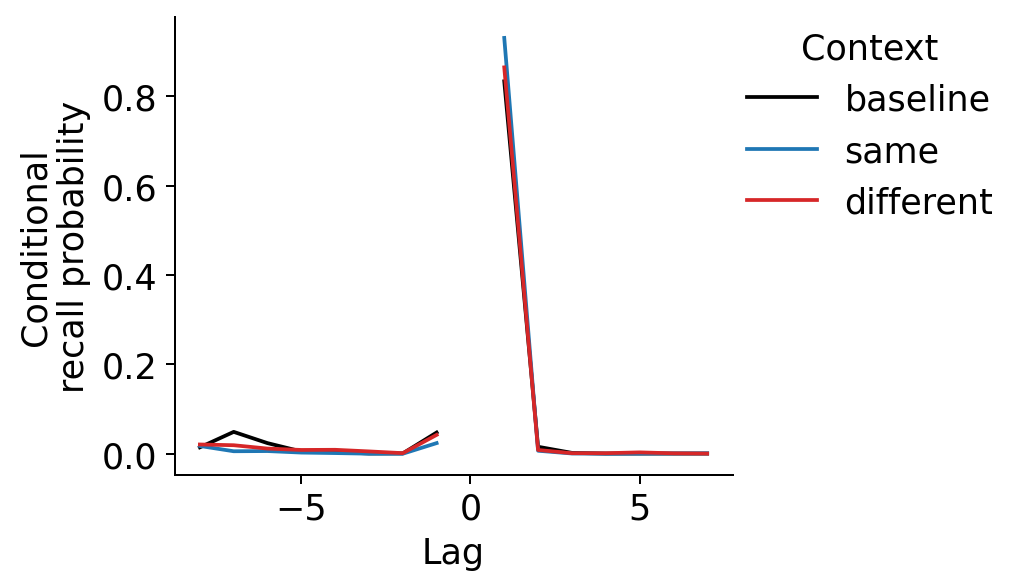

In [91]:
crp_by_noise_std = df_samediff.groupby("noise_type_int")["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std = []
for name, group in crp_by_noise_std:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std.append(mean_crp)
mean_crp_by_noise_std = np.array(mean_crp_by_noise_std)

colors = ["black", "tab:blue", "tab:red"]
plot_crp_by_group(mean_crp_by_noise_std, ["baseline", "same", "different"], "Context", colors)


### cluster with original data and figure out clusters

In [162]:
""" load vary gamma """

gamma_names = ["0", "02", "04", "06", "08", "10"]
temporal_discount_factors = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
noise_levels = [0, 0.2, 0.4, 0.6, 0.8, 1]
noise_names = ["0", "02", "04", "06", "08", "1"]

data = []

data_folder = Path("./experiments/VaryAllSeq8/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/VaryAllSeq8/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/VaryAllSeq8/figures/perturbation/ValueMemoryGRU")
item_invariance_folder = Path("./experiments/VaryAllSeq8/figures/item_invariant/ValueMemoryGRU")
time_invariance_folder = Path("./experiments/VaryAllSeq8/figures/time_invariant/ValueMemoryGRU")
seq_len = 8

exp = "tdf"

for gamma_name, temporal_discount_factor in zip(gamma_names, temporal_discount_factors):
    for noise_name, noise_level in zip(noise_names, noise_levels):
        setup_name = "setup_gamma{}_noise{}".format(gamma_name, noise_name)

        parameters = {
            "temporal_discount_factor": temporal_discount_factor,
            "noise_level": noise_level,
            "seq_len": seq_len,
        }
        
        training_data_length = 200
        for i in range(20):
            data_path = data_folder / setup_name / str(i)
            training_data_path = training_curve_folder / (setup_name + "-" + str(i))
            if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
                data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
                if data_single_model:
                    data_single_model["pretrained"] = False
                    perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                    data_single_model["perturbation_accuracy"] = perturbation_data
                    if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["item_invariance_accuracy"] = item_invariance_data
                        # item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        # data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                    else:
                        data_single_model["item_invariance_accuracy"] = None
                        # data_single_model["item_invariance_cross_phase_accuracy"] = None
                    if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["time_invariance_accuracy"] = time_invariance_data
                        # time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        # data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                    else:
                        data_single_model["time_invariance_accuracy"] = None
                        # data_single_model["time_invariance_cross_phase_accuracy"] = None
                    data.append(data_single_model)

df = pd.DataFrame(data)
print(len(data))

717


In [153]:
""" load vary gamma large noise"""

data = []

data_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/VaryAllSeq8LargeNoise/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/perturbation/ValueMemoryGRU")
item_invariance_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/item_invariant/ValueMemoryGRU")
time_invariance_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/time_invariant/ValueMemoryGRU")
seq_len = 8

exp = "tdf_large_noise"

for gamma_name, temporal_discount_factor in zip(gamma_names, temporal_discount_factors):
    for noise_name, noise_level in zip(noise_names, noise_levels):
        setup_name = "setup_gamma{}_noise{}".format(gamma_name, noise_name)

        parameters = {
            "temporal_discount_factor": temporal_discount_factor,
            "noise_level": noise_level,
            "seq_len": seq_len,
        }
        
        training_data_length = 200
        for i in range(20):
            data_path = data_folder / setup_name / str(i)
            training_data_path = training_curve_folder / (setup_name + "-" + str(i))
            if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
                data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
                if data_single_model:
                    data_single_model["pretrained"] = False
                    perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                    data_single_model["perturbation_accuracy"] = perturbation_data
                    if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["item_invariance_accuracy"] = item_invariance_data
                        # item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        # data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                    else:
                        data_single_model["item_invariance_accuracy"] = None
                        # data_single_model["item_invariance_cross_phase_accuracy"] = None
                    if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["time_invariance_accuracy"] = time_invariance_data
                        # time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        # data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                    else:
                        data_single_model["time_invariance_accuracy"] = None
                        # data_single_model["time_invariance_cross_phase_accuracy"] = None
                    data.append(data_single_model)

df = pd.DataFrame(data)
print(len(data))

699


In [171]:
# df_filtered = df[(df["accuracy"]>0.65) & (df["temporal_factor"] >= 0.4)]


# df_filtered = df[(df["accuracy"] > 0.5)]
df_filtered = df[((df["temporal_discount_factor"] == 1.0) | (df["noise_level"] == 1.0)) & (df["accuracy"] > 0.7) & (df["temporal_factor"] >= 0.35)]
# df_filtered = df[(df["accuracy"] > 0.7) & (df["temporal_factor"] >= 0.42)]
# df_filtered = df[(df["accuracy"] > 0.6) & (df["temporal_factor"] >= 0.35)]
print(len(df_filtered))

194


In [172]:
# make the optimal number of clusters

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["forward_asymmetry", "temporal_factor",
            # "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy", 
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity"]

X = df_filtered[features]

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Fit the KMeans model with the optimal number of clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_normalized)
df_filtered.loc[:, 'cluster'] = cluster_labels

# Add silhouette score to evaluate clustering quality
silhouette_avg = silhouette_score(X_normalized, cluster_labels)
print(f'Silhouette Score for {optimal_clusters} clusters: {silhouette_avg}')


# print number of items for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}: {len(df_filtered[df_filtered["cluster"] == i])} items')
# print 5 info for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}:')
    print(df_filtered[df_filtered['cluster'] == i][["temporal_discount_factor", "noise_level", "model_num"]].tail())



Silhouette Score for 3 clusters: 0.4698340907630753
Cluster 1: 58 items
Cluster 2: 80 items
Cluster 3: 56 items
Cluster 1:
     temporal_discount_factor  noise_level  model_num
711                       1.0          1.0         14
712                       1.0          1.0         15
713                       1.0          1.0         16
714                       1.0          1.0         17
716                       1.0          1.0         19
Cluster 2:
     temporal_discount_factor  noise_level  model_num
689                       1.0          0.8         12
690                       1.0          0.8         13
691                       1.0          0.8         14
692                       1.0          0.8         15
696                       1.0          0.8         19
Cluster 3:
     temporal_discount_factor  noise_level  model_num
669                       1.0          0.6         12
677                       1.0          0.8          0
693                       1.0          0.8   

/state/partition1/job-2016569/ipykernel_2390709/2702662253.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.loc[:, 'cluster'] = cluster_labels


194


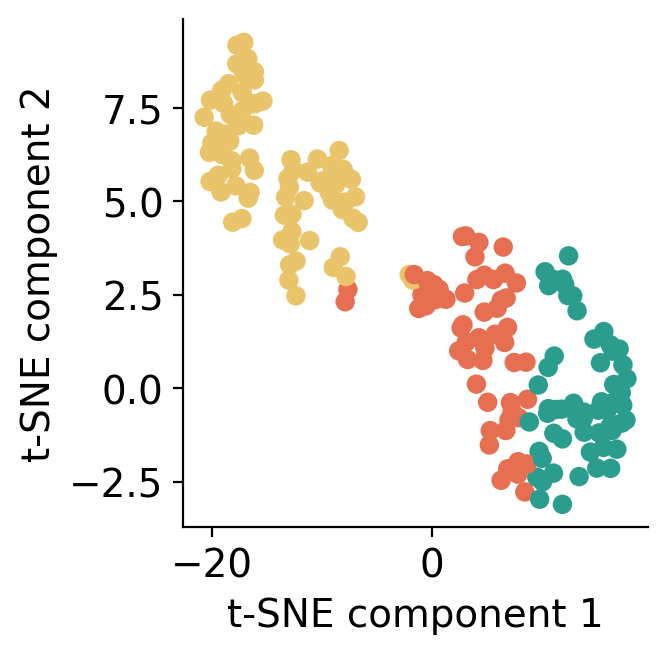

In [173]:
from sklearn.manifold import TSNE

colormap = np.array(["#2A9D8F", "#E9C46A", "#E76F51", "#F4A261", "#264653"])


# df_filtered = df_filtered[(df_filtered["temporal_discount_factor"] == 1.0) | (df_filtered["noise_level"] == 1.0)]
print(len(df_filtered))

X_tsne = df_filtered[features]

scaler = StandardScaler()
X_tsne_normalized = scaler.fit_transform(X_tsne)
cluster_labels = df_filtered["cluster"]



# Perform t-SNE on the normalized data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_normalized)

# Plot the t-SNE results with cluster labels
plt.figure(figsize=(3, 3.3), dpi=200)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colormap[cluster_labels])
# plt.title('t-SNE visualization of clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


In [174]:
# distribution of strategies in each factor

def plot_bar_by_strategy(df, x, x_label, fig_width=3.2, bar_width=0.12, row_labels=None):
    plt.figure(figsize=(fig_width, 3.3), dpi=180)
    
    cluster_distribution = df.groupby(["cluster", x]).size().unstack(fill_value=0)
    sum_distribution = cluster_distribution.sum(axis=0)
    cluster_distribution = cluster_distribution.div(sum_distribution, axis=1)
    cumsum_distribution = cluster_distribution.cumsum(axis=0)

    for i, row in cumsum_distribution.iterrows():
        plt.bar(row.index, row.values, color=colormap[i], label=f"Cluster {i}", width=bar_width, zorder=-i)
    plt.xlabel(x_label)
    plt.ylabel("Distribution of strategies")

    unique_x = df[x].unique()
    if row_labels is not None:
        assert len(row_labels) == len(unique_x)
        plt.xticks(unique_x, row_labels)
    else:
        plt.xticks(unique_x, unique_x)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()


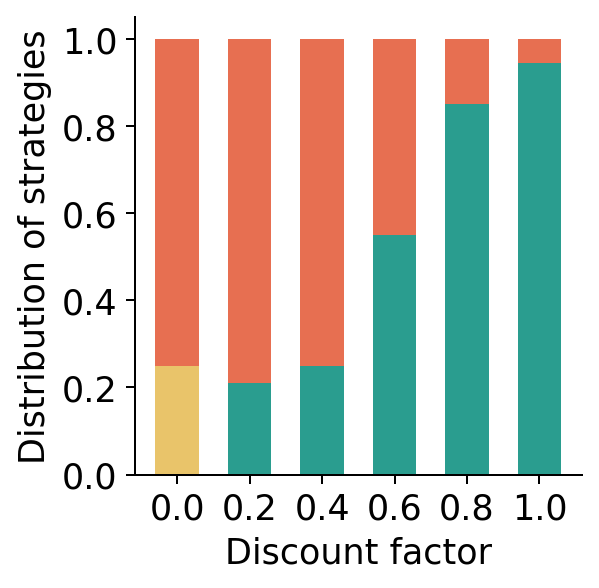

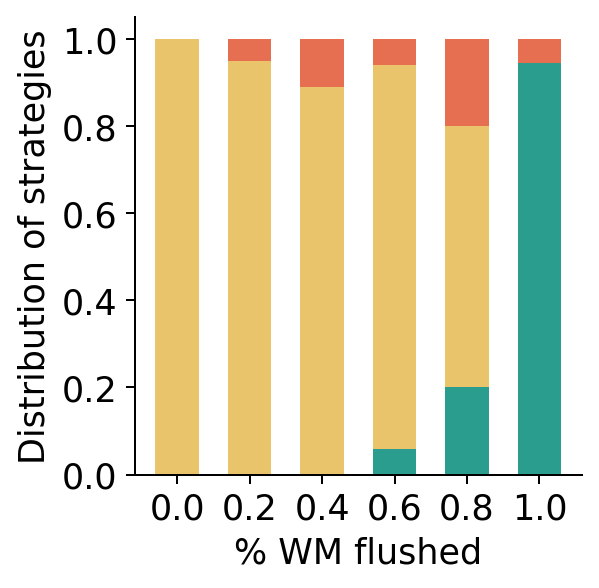

In [175]:
df_all_tdf = df_filtered[df_filtered["noise_level"] == 1.0]
# df_all_tdf = df_filtered
plot_bar_by_strategy(df_all_tdf, "temporal_discount_factor", "Discount factor")

df_all_noise = df_filtered[df_filtered["temporal_discount_factor"] == 1.0]
# df_all_noise = df_filtered
plot_bar_by_strategy(df_all_noise, "noise_level", "% WM flushed")

# plot_bar_by_strategy(df_filtered, "temporal_discount_factor", "Discount factor")
# plot_bar_by_strategy(df_filtered, "noise_level", "% WM flushed")


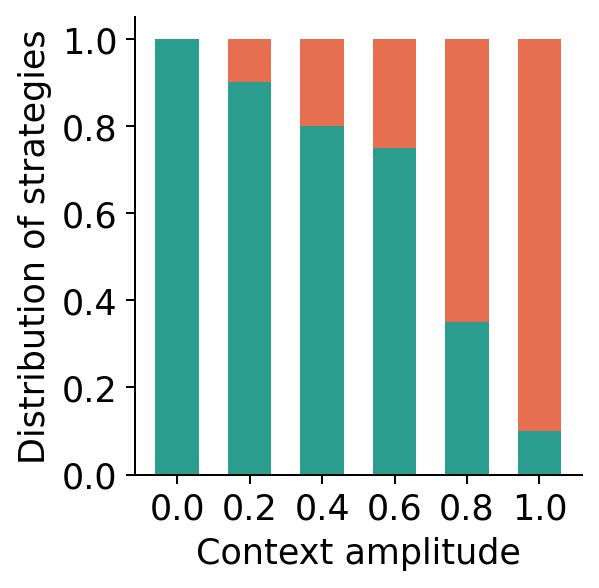

In [176]:

# print(df_perf1_filtered.keys())
# print(df_perf2_filtered.keys())


# df_perf1_filtered = df_perf1[(df_perf1["temporal_factor"] >= 0.35)]
# df_perf2_filtered = df_perf2[(df_perf2["temporal_factor"] >= 0.35)]
X_ctx = df_ctx[features]
X_ctx_normalized = scaler.transform(X_ctx)
cluster_labels_ctx = kmeans.predict(X_ctx_normalized)
df_ctx.loc[:, "cluster"] = cluster_labels_ctx
plot_bar_by_strategy(df_ctx, "noise_std", "Context amplitude")





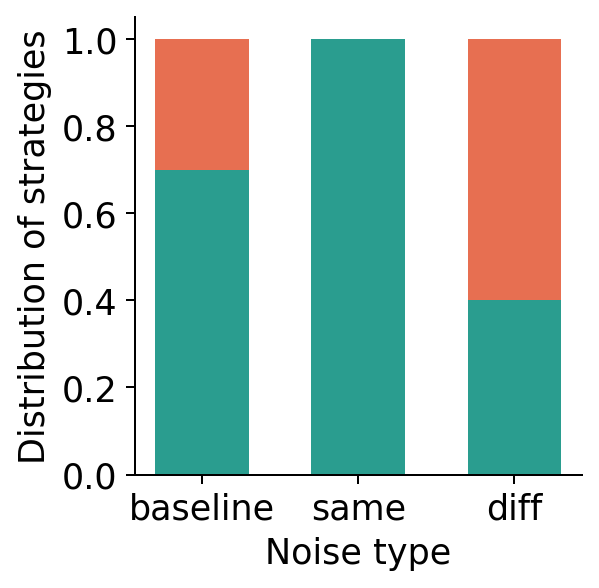

In [161]:


# print(df_perf1_filtered.keys())
# print(df_perf2_filtered.keys())


# df_perf1_filtered = df_perf1[(df_perf1["temporal_factor"] >= 0.35)]
# df_perf2_filtered = df_perf2[(df_perf2["temporal_factor"] >= 0.35)]
X_samediff = df_samediff[features]
X_samediff_normalized = scaler.transform(X_samediff)
cluster_labels_samediff = kmeans.predict(X_samediff_normalized)
df_samediff.loc[:, "cluster"] = cluster_labels_samediff
plot_bar_by_strategy(df_samediff, "noise_type_int", "Noise type", fig_width=3.2, bar_width=0.6, row_labels=["baseline", "same", "diff"])


